# <--------- Session-7 --------->

In [3]:
import pandas as pd

Task.1 :- Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating' column using the IQR method and print the indices of the detected outliers.


In [4]:
a = pd.read_csv(r"C:\PYTHON\Assignments-\Libraries\Session-6\zomato_dataset.csv")
a

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...
123652,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Reshmi Kebab,NaN,0,525.0
123653,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Large Tikka,NaN,0,525.0
123654,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Chukandri Tikka,NaN,0,525.0
123655,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Golden Kebab,NaN,0,525.0


In [18]:
df = a[["Restaurant Name","Dining Rating"]]
df

,Restaurant Name,Dining Rating
0,Doner King,3.9
1,Doner King,3.9
2,Doner King,3.9
3,Doner King,3.9
4,Doner King,3.9
...,...,...
123652,Ariena Boutique Hotel,3.9
123653,Ariena Boutique Hotel,3.9
123654,Ariena Boutique Hotel,3.9
123655,Ariena Boutique Hotel,3.9


In [24]:
Q1 = df["Dining Rating"].quantile(0.25)
Q2 = df["Dining Rating"].quantile(0.75)
IQR = Q2 - Q1

lower = Q1 - (1.5 * IQR)
higher = Q2 + (1.5 * IQR)

outliers = df[(df["Dining Rating"] < lower) | (df["Dining Rating"] > higher)]

print("Indicated Outliers :")
print(outliers)

Indicated Outliers :
                         Restaurant Name  Dining Rating
5046    Capital Multi Cuisine Restaurant            2.7
5047    Capital Multi Cuisine Restaurant            2.7
5048    Capital Multi Cuisine Restaurant            2.7
5049    Capital Multi Cuisine Restaurant            2.7
5050    Capital Multi Cuisine Restaurant            2.7
...                                  ...            ...
103794                 Goli Vadapav No.1            2.8
103795                 Goli Vadapav No.1            2.8
103796                 Goli Vadapav No.1            2.8
103797                 Goli Vadapav No.1            2.8
103798                 Goli Vadapav No.1            2.8

[1864 rows x 2 columns]


Task. 2 :- Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, and visually identify any outliers present.<br><br><em><strong>Hint:</strong> Use plt.boxplot() and label your axes for clarity.</em>


In [33]:
import matplotlib.pyplot as plt
import numpy as np

In [42]:
order_amount = a[["Restaurant Name","Prices"]]
c = order_amount.sample(100).head(10)

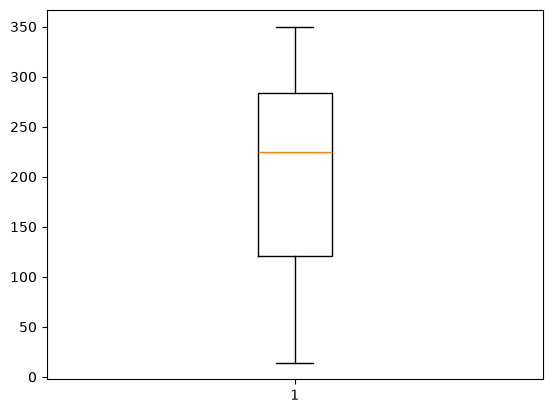

In [51]:
x = np.array(c["Restaurant Name"])
y = np.array(c["Prices"])

plt.boxplot(y,label = "Prices")
plt.show()

In [53]:
"""
The region above and below the box is the outliers
"""
print()

Task.3 :- Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap all values above the 95th percentile and below the 5th percentile, then display the updated column statistics.


In [89]:
transaction_amount = { 
    "Amount" : [450,600,562,654,254,350,1050,250,900,1000]
}
df2 = pd.DataFrame(transaction_amount)
df2

,Amount
0,450
1,600
2,562
3,654
4,254
5,350
6,1050
7,250
8,900
9,1000


In [90]:
Q1 = df2["Amount"].quantile(0.05)
Q2 = df2["Amount"].quantile(0.95)

# winsorization:-

df2["Amount"]= df2["Amount"].clip(lower= Q1,upper=Q2)

df2.sort_values("Amount",axis = 0)

,Amount
7,251.8
4,254.0
5,350.0
0,450.0
2,562.0
1,600.0
3,654.0
8,900.0
9,1000.0
6,1027.5


Task.4 :- You have a DataFrame of Flipkart product prices stored as strings with currency symbols (e.g., '₹1,299'). Convert this column to numeric type using pandas, ensuring all non-numeric characters are removed.<br><br><em><strong>Hint:</strong> Use str.replace() and astype().</em>

In [95]:
a = {"Price" : ['₹1,300','₹2,299','₹3,299','₹4,299','₹5,299','₹6,299']}
df3 = pd.DataFrame(a)
df3

,Price
0,"₹1,300"
1,"₹2,299"
2,"₹3,299"
3,"₹4,299"
4,"₹5,299"
5,"₹6,299"


In [99]:
df3["Price"] = df3["Price"].str.replace("₹","").str.replace(",","").astype(int)

In [102]:
df3["Price"]

0    1300
1    2299
2    3299
3    4299
4    5299
5    6299
Name: Price, dtype: int64

Task.5 :- Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of boolean, string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 'yes' as True, and everything else as False.


In [106]:
spotify= {
    "is_premium" : ["Yes","No","Yes","Yes",1,0,0,0,1,True,False,True]
}

user = pd.DataFrame(spotify)
user

,is_premium
0,Yes
1,No
2,Yes
3,Yes
4,1
5,0
6,0
7,0
8,1
9,True


In [109]:
user["is_premium"] = user["is_premium"].astype(str).isin(["True","1","Yes"])
user

,is_premium
0,True
1,False
2,True
3,True
4,True
5,False
6,False
7,False
8,True
9,True
